In [ ]:
pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier


In [21]:
df = pd.read_csv("/content/stock_data.csv")

# data cleaning, encoding and handling null values

df.drop_duplicates(inplace = True)

for col in df:
  if df[col].dtype == "object":
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


columns = [df.columns[i] for i in range(len(df.columns))]

imputer = SimpleImputer(strategy="most_frequent")
for col in columns:
  if col in df:
    if df[col].dtype!= "object" and df[col].isnull().sum() > 0:
      df.fillna(df[col].mean(), inplace=True)
    else:
      imputer.fit(df[[col]])
      df[col] = imputer.transform(df[[col]])

df.drop_duplicates(inplace = True)

df.dropna(inplace = True)

y = df['Stock_5']
x = df.drop('Stock_5', axis = 1)

# smote = SMOTE()
# x = df

# x_resampled, y_resampled = smote.fit_resample(x, y)


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

print(f"""

AFTER SMOTE


df.shape : {df.shape}
x_train : {x_train.shape}
x_test : {x_test.shape}
y_train : {y_train.shape}
y_test : {y_test.shape}
""")



AFTER SMOTE


df.shape : (365, 6)
x_train : (292, 5)
x_test : (73, 5)
y_train : (292,)
y_test : (73,)



In [27]:
df.rename(columns={df.columns[0]: 'date'}, inplace=True)

In [25]:
print(df)

     date     Stock_1     Stock_2    Stock_3     Stock_4     Stock_5
0       0  101.764052  100.160928  99.494642   99.909756  101.761266
1       1  102.171269   99.969968  98.682973  100.640755  102.528643
2       2  103.171258   99.575237  98.182139  100.574847  101.887811
3       3  105.483215   99.308641  97.149381  100.925017  101.490049
4       4  107.453175   98.188428  99.575396  101.594411  101.604283
..    ...         ...         ...        ...         ...         ...
360   360   92.684784   63.408103  98.288992  117.788079  102.995720
361   361   92.688279   62.816639  98.061845  116.605106  102.718260
362   362   93.551993   63.597651  96.454800  115.441164  103.566068
363   363   93.870037   64.114492  95.747485  113.856107  103.257107
364   364   93.855317   64.491011  97.805648  112.640418  102.304226

[365 rows x 6 columns]


In [28]:
print(y_train)

211    105.198735
340    107.969458
202    107.076296
75     102.259481
84     101.007222
          ...    
71     104.727134
106    106.322661
270    106.314679
348    107.275627
102    105.376602
Name: Stock_5, Length: 292, dtype: float64


In [32]:
from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    median_absolute_error,
    explained_variance_score  )

xgb_model = XGBRegressor(
   n_estimators=300,
    learning_rate=0.1,
    max_depth=5,

    random_state=42,
    n_jobs=-1,

    colsample_bytree=0.7,
    subsample=0.8,

    objective='reg:squarederror',
    tree_method='auto')

xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)

# accuracy_scores = accuracy_score(y_test, y_pred)
# precision_scores = precision_score(y_test, y_pred)
# recall_scores = recall_score(y_test, y_pred)
# f1_scores = f1_score(y_test, y_pred) # caluculate metrics considering class imbalance

# print(f"""
# Accuracy Score : {accuracy_scores}
# Precision Score : {precision_scores}
# Recall Score : {recall_scores}
# F1 Score : {f1_scores} """)

r2_score = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R2 Score: {r2_score}")
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")

R2 Score: 0.9064181706036343
Mean Absolute Error: 0.9378525020592383
Mean Squared Error: 1.46529972729121


In [33]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import matplotlib.pyplot as plt

# # Compute the confusion matrix
# cm = confusion_matrix(y_test, y_pred)

# # Display the confusion matrix
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass']) # Assuming binary classification for 'liked'
# disp.plot(cmap=plt.cm.Blues)
# plt.xlabel('Predicted student data')
# plt.ylabel('True')
# plt.title('Confusion Matrix')
# plt.show()

In [36]:
# print(classification_report(y_test, y_pred))

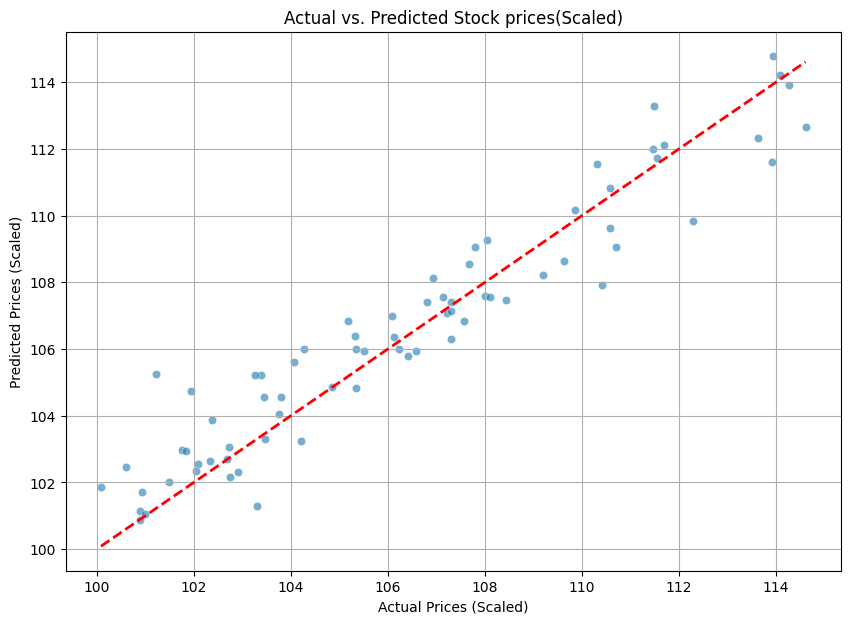

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.title('Actual vs. Predicted Stock prices(Scaled)')
plt.xlabel('Actual Prices (Scaled)')
plt.ylabel('Predicted Prices (Scaled)')
plt.grid(True)
plt.show()

In [39]:
import joblib
if joblib.dump(xgb_model, 'stock_price_prediction.pkl'):
  print("model saved")

model saved
